# Tuto_003 : Predictor/Corrector 

The purpose of this tutorial is to introduce the concept of continuation procedure. The continuation procedure consists in a prediction/correction procedure that would increase drastically the chances of the nonlinear solver to be able to converge. It also allows the code to pass through complex points such as bifurcations. 

The tutorial is based on the pendulum equations that have been used in the last tutorial and is following the agenda given below : 
1. Why use a predictor ? 
2. Some flexibility thanks to the correctors
3. Turning points and the importance of bifurcations


In [1]:
## This block makes the mandatory imports and configure matplotlib for figures
## Some help function is also define here (get_frf)
import sys

PATH_TO_PYHARM = False
PATH_TO_PYHARM = "../"
if PATH_TO_PYHARM != False:
    sys.path.append(PATH_TO_PYHARM)
# ------------------ IMPORTS ------------------ #
import copy
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import scipy.io

import pyHarm
from pyHarm.Elements.ABCElement import ABCElement
from pyHarm.Elements.FactoryElements import ElementDictionary

# ------------------ MATPLOTLIB DEFAULT STYLE ------------------ #
plt.style.use("default")
FONT_BASE = 25
width_fig = 15
ratio_fig = (width_fig, 1 / (16 / 10.0) * width_fig)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
plt.rc("xtick", labelsize=FONT_BASE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=FONT_BASE)  # fontsize of the tick labels
plt.rc("legend", fontsize=FONT_BASE)  # legend fontsize
plt.rc("axes", labelsize=FONT_BASE)
plt.rc("axes", titlesize=FONT_BASE + 5)  # fontsize of the title

style_plots_ref = {
    "frf_lin": {
        "linestyle": "dashed",
        "color": np.array([0, 0, 0]),
        "label": "Linear solution",
    },
    "frf_lin_nothing": {
        "linestyle": "dashed",
        "color": np.array([0, 0.25, 1.0]),
        "label": "Linear solution no prediction nor correction",
        "linewidth": 2,
        "marker": "o",
    },
    "frf_lin_pred": {
        "linestyle": "dashed",
        "color": np.array([1, 0.25, 0]),
        "label": "Linear solution with prediction",
        "linewidth": 2,
        "marker": "s",
    },
    "frf_lin_predcor": {
        "linestyle": "dashed",
        "color": np.array([0.2, 1.0, 0.2]) * 0.7,
        "label": "Linear solution with prediction and correction",
        "linewidth": 2,
        "marker": "d",
    },
    "frf_nl_cubic": {
        "linestyle": "solid",
        "linewidth": 2,
        "color": np.array([255, 140, 0]) / 255.0,
        "marker": ".",
        "label": "nonlinear solution with cubic connector",
    },
    "frf_nl_cubicB": {
        "linestyle": "solid",
        "linewidth": 2,
        "color": np.array([0, 140, 255]) / 255.0,
        "marker": ".",
        "label": "nonlinear solution with cubic connector backward",
    },
    "frf_nl_bifurc": {
        "linestyle": "solid",
        "linewidth": 2,
        "color": np.array([255 / 8.0, 255, 255 / 8.0]) / 255.0,
        "marker": ".",
        "label": "nonlinear solution with bifurcation detection",
    },
    "frf_nl_sin": {
        "linestyle": "solid",
        "linewidth": 2,
        "color": np.array([0, 140, 255]) / 255.0,
        "marker": ".",
        "label": "nonlinear solution with true sinus connector",
    },
}
SAVE = False


# ------------------ function for FRF ------------------ #
def get_frf(M, indices_selection=("sub1", 0, 0), analysis="FRF"):
    indexH = M.getIndex(*indices_selection)
    SA = [sol for sol in M.nls[analysis].SolList if sol.flag_accepted]
    om = np.array([sol.x[-1] for sol in SA])
    ampH = np.array([np.linalg.norm(sol.x[indexH]) for sol in SA])
    return SA, om, ampH

## Why use a predictor ? 

Because nonlinear solvers are not globally convergent but only locally, it is important to give as a starting point a good initial guess. In pyHarm, there exists some of the most classical predictors in order to give a good initial guess to the nonlinear solver. In this part of the tutorial we propose to the users to code a predictor that would give the null vector as a predictor at each step. 

### Construction of a new stopping criterion

Because the code will fail to converge properly in this exercises, a new stopping criterion is first constructed. This stopping criterion analyses the number of solution points that have not reached convergence (meaning the nonlinear solver has not been able to solve the problem correctly) and stops the analysis if too many failures have been obtained.
- Complete the `failnumber_reached` function in order to stop the analysis whenever the solver has failed too many times to converge 


In [2]:
from Tuto_003_predictorcorrector_correctionfunctions import failnumber_reached_corr

from pyHarm.BaseUtilFuncs import pyHarm_plugin
from pyHarm.Solver import FirstSolution, SystemSolution
from pyHarm.StopCriterion.FactoryStopCriterion import StopCriterionBounds, Stopper_dico


### USER MODIFICATIONS ATTENDED ###
def failnumber_reached(
    sollist: list[SystemSolution], failnumber_threshold: int, stop: bool
) -> bool:
    """sollist contains all the solution points that have been seen during the analysis
    including the false convergence. A solution inside the sollist has been rejected if
    the flag solution.flag_accepted is set to False.
    Provides a function that returns True if the number of fail is higher that the threshold"""
    return True  # to be modified


### END USER MODIFICATION ###


class StopCriterionFailNumber(StopCriterionBounds):
    factory_keyword = "fail"
    fail_accepted = 10  # you can play with this value

    def getStopCriterionStatus(
        self, sol: SystemSolution, sollist: list[SystemSolution], **kwargs
    ) -> bool:
        stop = super().getStopCriterionStatus(sol, sollist, **kwargs)
        stop = failnumber_reached_corr(
            sollist, self.fail_accepted, stop
        )  # here is your coded function
        return stop


pyHarm_plugin(StopCriterionFailNumber)

### Construction of a null predictor 

In order to better apprehend the importance of the predictors, we propose here to code the worst kind of predictor and use it in the pendulum problem to see its effect. The worst predictor would be to initialize the starting point to be the null vector. 
- Complete the `compute_direction` function in order to obtain the direction of the guess of the next point
- Complete the `xpred_null_guess` function in order to obtain the null vector as a starting point for the next step of the analysis

In [3]:
from Tuto_003_predictorcorrector_correctionfunctions import (
    compute_direction_corr,
    xpred_null_guess_corr,
)

from pyHarm.Predictors.FactoryPredictor import ABCPredictor, Predictor_dico


### USER MODIFICATIONS ATTENDED ###
def compute_direction(x_size: int) -> np.ndarray:
    """Computes the direction of the guess for the next point.
    The angular frequency is the last element in the vector ([-1])."""
    pass  # to be modified


def xpred_null_guess(
    lstp_x: np.ndarray, direction: np.ndarray, ds: float, sign_ds: int
) -> np.ndarray:
    """Computes the x predicted using the direction of prediction,
    the step size and its sign, and the vector of the last accepted point.
    Remember to use the angular frequency of the last solution point lstp_x[-1]"""
    pass  # to be modified


### END USER MODIFICATION ###


class PredictorNullSolution(ABCPredictor):
    """Defines the null solution type of predictor."""

    predictor_name = "Null Solution Predictor"
    factory_keyword = "null"

    def predict(
        self, sollist: list[SystemSolution], ds: float, k_imposed=None
    ) -> tuple[np.ndarray, SystemSolution, float]:
        lstpt = self.getPointerToSolution(
            sollist, k_imposed
        )  # get associated last accepted point
        lstpt.getJacobian("full")  # get the Jacobian of the previous accepted point
        self.bifurcation_detect(lstpt)  # Detect if bifurcation is present

        lstp_x = lstpt.x  # last accepted point solution vector
        ### CHANGE FUNCTIONS BELOW TO YOUR OWN
        direction = compute_direction_corr(
            lstp_x.size
        )  # get the direction of prediction
        xpred = xpred_null_guess_corr(lstp_x, direction, ds, self.sign_ds)

        lstpt.dir = direction
        lstpt.x_pred = xpred
        return xpred, lstpt, self.sign_ds


pyHarm_plugin(PredictorNullSolution)

In [4]:
# ------------------ SYSTEM CONSTRUCTION ------------------ #
m = 30.0
g = 9.81
R = 1.0 * 2
C = 1e-1
FE = 1.2e1 + 4.0

MassMatrix = np.array([[1.0]])
DampMatrix = C * np.array([[1.0]])
RigidMatrix = np.array([[g / R]])
LinSys = dict()
LinSys["M"] = MassMatrix
LinSys["C"] = DampMatrix
LinSys["K"] = 0 * RigidMatrix
LinSys["G"] = 0 * MassMatrix


# ------------------ INPUT CONSTRUCTION ------------------ #
INP = {
    "analysis": {
        "FRF": {
            "study": "frf",
            "puls_inf": 0.1,
            "puls_sup": 7.0,
            "ds_min": 1e-12,
            "ds0": 3e-3,
            "ds_max": 3e-3,
            "sign_ds": 1,
            "verbose": True,
            "solver": "scipyroot",
            "predictor": "null",
            "corrector": "nocontinuation",
            "stopper": "fail",
            "stepsizer": "constant",
            "predictor_options": {"verbose": True},
        }
    },
    "system": {
        "type": "Base",
        "nh": 5,
        "nti": 128,
        "adim": {"status": False, "lc": 1.0, "wc": 1.0},
    },
    "substructures": {"sub1": {"matrix": LinSys, "ndofs": 1}},
    "connectors": {
        "loading": {
            "type": "CosinusForcing",
            "connect": {"sub1": [0]},
            "dirs": [0],
            "amp": FE / (m * R),
        },
    },
}


INP_lin = copy.deepcopy(INP)  # new input from the template
# A new connector is added
INP_lin["connectors"]["linGravity"] = {
    "type": "LinearSpring",
    "connect": {"sub1": [0]},
    "dirs": [0],
    "k": g / R,
}

In [5]:
Lin_nothing = pyHarm.Maestro(INP_lin)  # Creation of the Maestro
Lin_nothing.operate("null")  # Run the analysis with the "null" guess as starting point

solution converged at om=0.1
solution converged at om=0.10300000000000001
solution converged at om=0.10600000000000001
solution converged at om=0.10900000000000001
solution converged at om=0.11200000000000002
solution converged at om=0.11500000000000002
solution converged at om=0.11800000000000002
solution converged at om=0.12100000000000002
solution converged at om=0.12400000000000003
solution converged at om=0.12700000000000003
solution converged at om=0.13000000000000003
solution converged at om=0.13300000000000003
solution not accepted at om=0.13600000000000004
solution not accepted at om=0.13600000000000004
solution not accepted at om=0.13600000000000004
solution not accepted at om=0.13600000000000004
solution not accepted at om=0.13600000000000004
solution not accepted at om=0.13600000000000004
solution not accepted at om=0.13600000000000004
solution not accepted at om=0.13600000000000004
solution not accepted at om=0.13600000000000004
solution not accepted at om=0.13600000000000

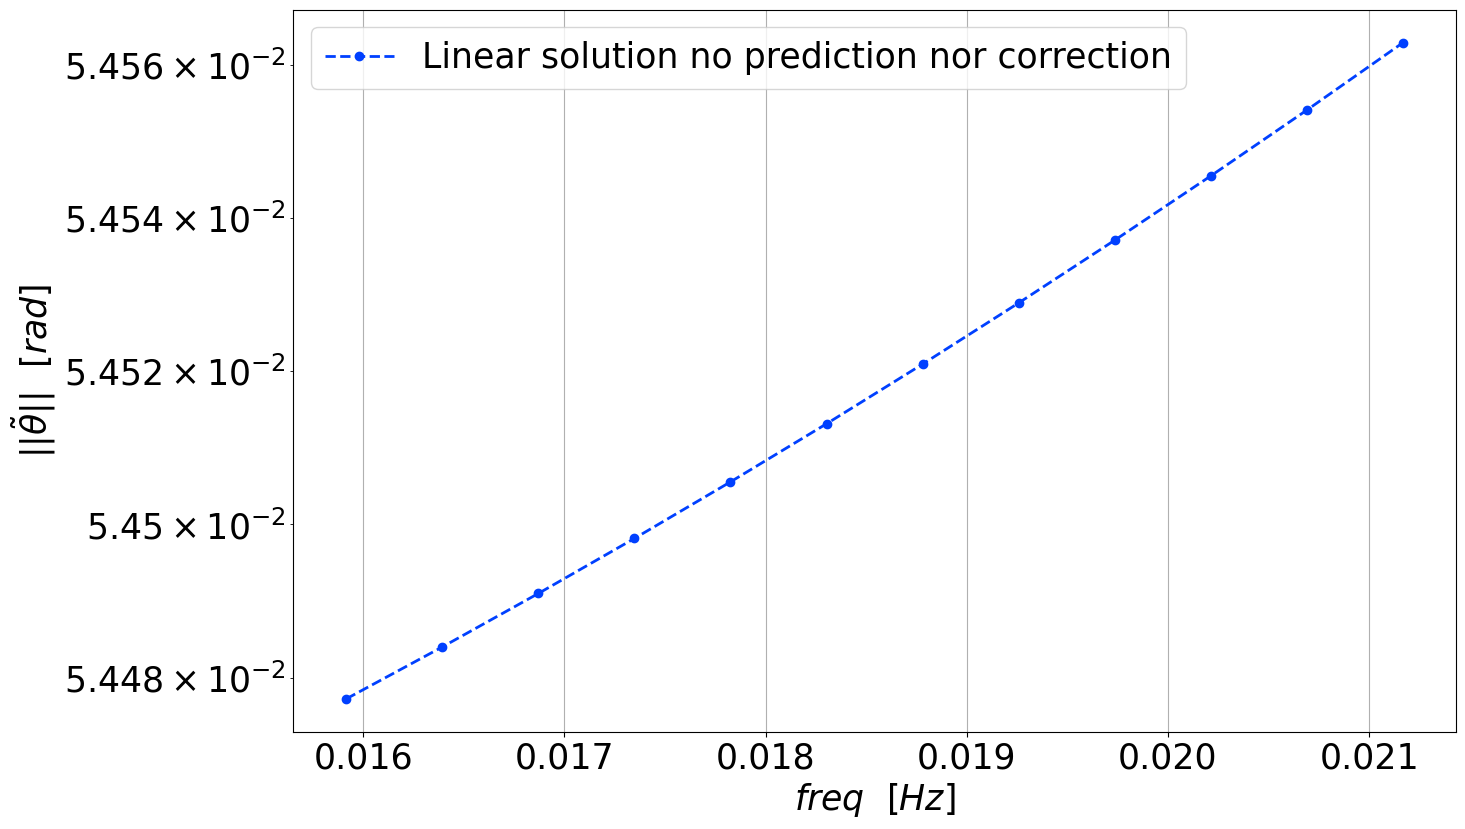

In [6]:
# -------------------- Draw of the frf -------------------- #
SA_lin_nothing, om_lin_nothing, ampH_lin_nothing = get_frf(
    Lin_nothing
)  # from the Maestro object, we extract some FRF by run the
# get_frf function defined at the top of the notebook

fig, ax = plt.subplots(figsize=ratio_fig)
ax.plot(
    om_lin_nothing / (2 * np.pi), ampH_lin_nothing, **style_plots_ref["frf_lin_nothing"]
)
ax.set_xlabel("$freq~~[Hz]$")
ax.set_ylabel("$\|\| \\tilde{\\theta} \|\|~~[rad]$")
ax.legend()
ax.grid()
ax.set_yscale("log")

The code is unable to converge due to the predictor that is giving a really bad guess as a starting point for the next step to be calculated. There exists numerous predictors that can be used, but two are the most popular : 
- **tangent predictor** : predict a point using the Jacobian information at the previous solution point. A tangent of the R(x)=0 is drawn and used as a direction to make a prediction for the next point
- **secant predictor** : this predictor uses the secant between the last two converged points to draw a direction from which the next guess is made. This predictor requires lower order information and is thus less precise, but can become more robust in badly conditioned areas

Some other predictor can be drawn from the same type of ideas by using second order information from the Hessian, or making a mix between tangent and secant. Last, a predictor that is less efficient but really easy consists in taking the previous solution as a guess

In the next block, the predictor is changed and the calculation is ran again. The student can try the other available predictors : 
- `previous`
- `secant`
- `tangent`


In [7]:
# -------------------- Linear problem -------------------- #
INP_pred = copy.deepcopy(INP_lin)
INP_pred["analysis"]["FRF"]["predictor"] = (
    "secant"  # you can play here with the different predictors
)
Pred = pyHarm.Maestro(INP_pred)
Pred.operate("null")

solution converged at om=0.1
solution converged at om=0.10299999071071471
solution converged at om=0.10599998119445098
solution converged at om=0.10899997121378018
solution converged at om=0.11199996075468863
solution converged at om=0.11499994980312017
solution converged at om=0.11799993834497495
solution converged at om=0.12099992636610805
solution converged at om=0.12399991385232827
solution converged at om=0.1269999007893968
solution converged at om=0.12999988716302596
solution converged at om=0.13299987295887786
solution converged at om=0.13599985816256305
solution converged at om=0.1389998427596393
solution converged at om=0.14199982673561024
solution converged at om=0.14499981007592394
solution converged at om=0.14799979276597167
solution converged at om=0.1509997747910865
solution converged at om=0.15399975613654196
solution converged at om=0.15699973678755066
solution converged at om=0.15999971672926294
solution converged at om=0.16299969594676544
solution converged at om=0.16

solution converged at om=0.7119617220159509
solution converged at om=0.7149611451716457
solution converged at om=0.717960561211793
solution converged at om=0.7209599700573572
solution converged at om=0.723959371628339
solution converged at om=0.7269587658437608
solution converged at om=0.7299581526216535
solution converged at om=0.7329575318790411
solution converged at om=0.7359569035319268
solution converged at om=0.7389562674952775
solution converged at om=0.7419556236830096
solution converged at om=0.7449549720079727
solution converged at om=0.7479543123819343
solution converged at om=0.7509536447155644
solution converged at om=0.7539529689184186
solution converged at om=0.7569522848989222
solution converged at om=0.7599515925643536
solution converged at om=0.7629508918208271
solution converged at om=0.7659501825732757
solution converged at om=0.7689494647254339
solution converged at om=0.7719487381798195
solution converged at om=0.7749480028377156
solution converged at om=0.7779472

solution converged at om=1.3473752130112309
solution converged at om=1.3503668304749719
solution converged at om=1.3533583231852555
solution converged at om=1.3563496889517899
solution converged at om=1.3593409255388649
solution converged at om=1.362332030664266
solution converged at om=1.3653230019981575
solution converged at om=1.3683138371619379
solution converged at om=1.371304533727061
solution converged at om=1.3742950892138275
solution converged at om=1.3772855010901426
solution converged at om=1.380275766770239
solution converged at om=1.3832658836133664
solution converged at om=1.3862558489224432
solution converged at om=1.3892456599426717
solution converged at om=1.392235313860115
solution converged at om=1.3952248078002343
solution converged at om=1.3982141388263858
solution converged at om=1.4012033039382743
solution converged at om=1.4041923000703649
solution converged at om=1.4071811240902496
solution converged at om=1.4101697727969675
solution converged at om=1.413158242

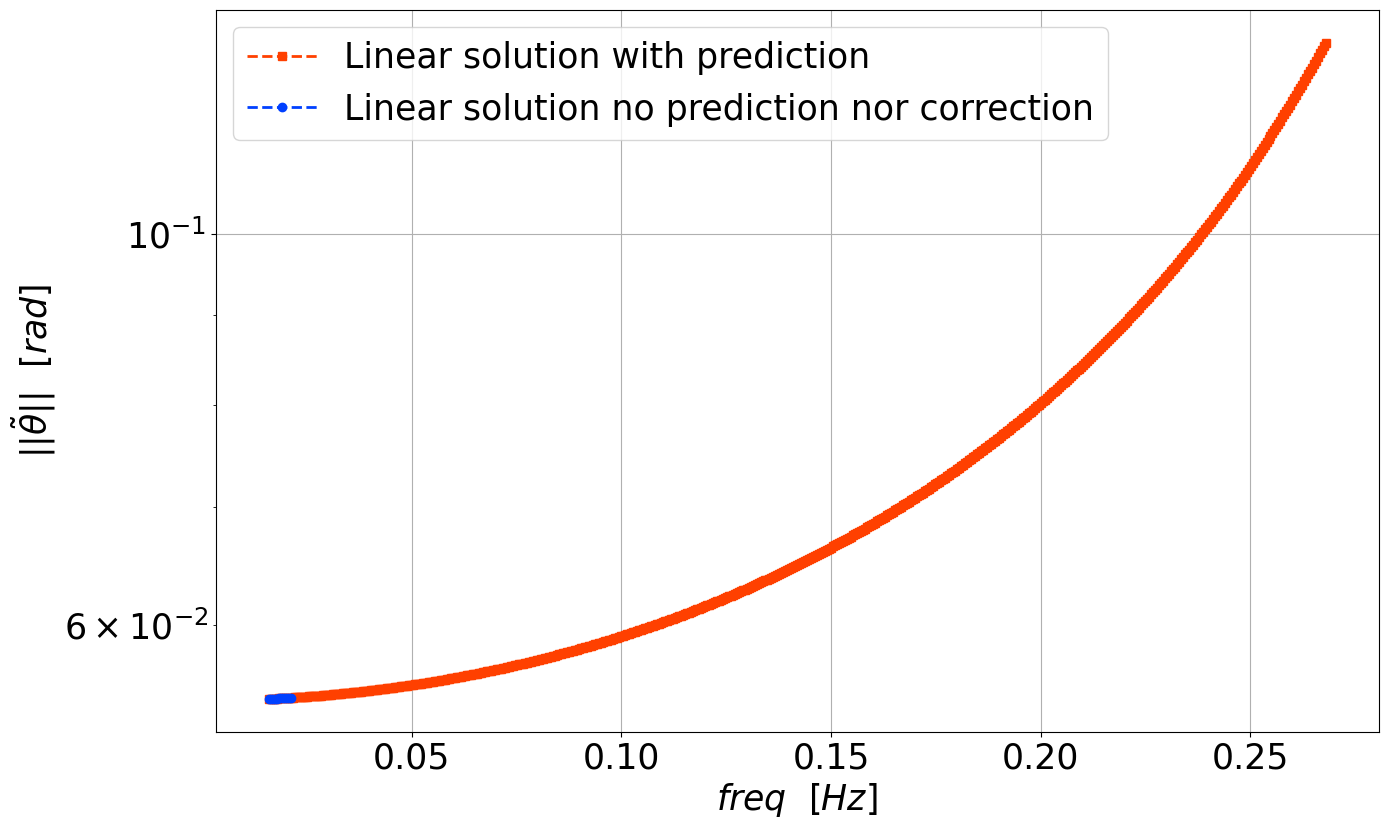

In [8]:
# -------------------- Draw of the frf -------------------- #
SA_pred, om_pred, ampH_pred = get_frf(Pred)

fig, ax = plt.subplots(figsize=ratio_fig)
ax.plot(om_pred / (2 * np.pi), ampH_pred, **style_plots_ref["frf_lin_pred"])
ax.plot(
    om_lin_nothing / (2 * np.pi), ampH_lin_nothing, **style_plots_ref["frf_lin_nothing"]
)
ax.set_xlabel("$freq~~[Hz]$")
ax.set_ylabel("$\|\| \\tilde{\\theta} \|\|~~[rad]$")
ax.legend()
ax.grid()
ax.set_yscale("log")

Even if the code shall have terminated further, the code has not been able to converge on the whole angular frequency range for certain predictors. This is partly due to the fact that solving the problem for a fixed angular frequency $\omega$ is quite challenging. 

## Some flexibility thanks to the correctors

The code is using what is called a continuation procedure. This procedure consists in adding the angular frequency $\omega$ as a variable in the HBM problem. Adding a new variable into the HBM system means that we miss one equation to complete the system. This missing equation is called the **correction equation**. There exists two main correction equation used, the most popular being called the `arc_length` correction. It gives the liberty of the solver to look for a solution in a larger space by having the capacity to modify the angular frequency value inside an hypersphere of radius equal to the distance between the last converged point and the new starting point. This flexibility is a god sent for the nonlinear solver and reduce drastically the failure chances.

An other popular correction equation is the `pseudo_arc_length` that consists in allowing the solver to look for a solution perpendicular to the prediction direction.

In the next block, the same test case is ran using the `arc_length` corrector.

In [9]:
# -------------------- Linear problem -------------------- #
INP_predcor = copy.deepcopy(INP_lin)  # new input from the template
INP_predcor["analysis"]["FRF"]["predictor"] = "secant"
INP_predcor["analysis"]["FRF"]["corrector"] = "arc_length"
PredCor = pyHarm.Maestro(INP_predcor)  # Creation of the Maestro
PredCor.operate("null")  # Run the analysis with the "null" guess as starting point

solution converged at om=0.1
solution converged at om=0.10299999048373629
solution converged at om=0.10599998050306556
solution converged at om=0.10899997004397415
solution converged at om=0.11199995909240593
solution converged at om=0.11499994763426102
solution converged at om=0.11799993565539454
solution converged at om=0.1209999231416153
solution converged at om=0.12399991007868448
solution converged at om=0.1269998964523144
solution converged at om=0.12999988224816722
solution converged at om=0.13299986745185347
solution converged at om=0.13599985204893092
solution converged at om=0.1389998360249032
solution converged at om=0.14199981936521844
solution converged at om=0.14499980205526786
solution converged at om=0.14799978408038456
solution converged at om=0.1509997654258421
solution converged at om=0.15399974607685307
solution converged at om=0.15699972601856785
solution converged at om=0.15999970523607307
solution converged at om=0.16299968371439033
solution converged at om=0.165

solution converged at om=0.663969581088569
solution converged at om=0.6669691021094142
solution converged at om=0.6699686170934344
solution converged at om=0.6729681259745215
solution converged at om=0.6759676286857882
solution converged at om=0.6789671251595569
solution converged at om=0.6819666153273489
solution converged at om=0.6849660991198724
solution converged at om=0.6879655764670115
solution converged at om=0.6909650472978146
solution converged at om=0.6939645115404817
solution converged at om=0.6969639691223529
solution converged at om=0.6999634199698964
solution converged at om=0.7029628640086952
solution converged at om=0.7059623011634353
solution converged at om=0.708961731357892
solution converged at om=0.7119611545149175
solution converged at om=0.714960570556427
solution converged at om=0.717959979403386
solution converged at om=0.7209593809757955
solution converged at om=0.7239587751926791
solution converged at om=0.7269581619720682
solution converged at om=0.729957541

solution converged at om=1.344375233746026
solution converged at om=1.347366851552893
solution converged at om=1.3503583446175194
solution converged at om=1.353349710750014
solution converged at om=1.3563409477150832
solution converged at om=1.359332053230944
solution converged at om=1.3623230249682106
solution converged at om=1.3653138605487476
solution converged at om=1.3683045575444943
solution converged at om=1.3712951134762559
solution converged at om=1.3742855258124616
solution converged at om=1.3772757919678895
solution converged at om=1.380265909302356
solution converged at om=1.3832558751193686
solution converged at om=1.386245686664743
solution converged at om=1.38923534112518
solution converged at om=1.3922248356268045
solution converged at om=1.3952141672336624
solution converged at om=1.3982033329461776
solution converged at om=1.4011923296995623
solution converged at om=1.404181154362187
solution converged at om=1.4071698037339009
solution converged at om=1.41015827454430

solution converged at om=2.0109138091277656
solution converged at om=2.012671681033448
solution converged at om=2.0144106314718
solution converged at om=2.016130719436589
solution converged at om=2.017832012578152
solution converged at om=2.019514586917041
solution converged at om=2.021178526545572
solution converged at om=2.0228239233189886
solution converged at om=2.024450876537929
solution converged at om=2.0260594926238413
solution converged at om=2.027649884788954
solution converged at om=2.0292221727023425
solution converged at om=2.0307764821535677
solution converged at om=2.0323129447152906
solution converged at om=2.033831697406193
solution converged at om=2.0353328823554397
solution converged at om=2.0368166464698407
solution converged at om=2.0382831411047793
solution converged at om=2.0397325217398867
solution converged at om=2.0411649476603424
solution converged at om=2.042580581644605
solution converged at om=2.0439795896592803
solution converged at om=2.04536214056175
so

solution converged at om=2.167837574714026
solution converged at om=2.168067798364232
solution converged at om=2.1682969761790973
solution converged at om=2.168525117993997
solution converged at om=2.168752233532437
solution converged at om=2.1689783324076695
solution converged at om=2.1692034241242855
solution converged at om=2.169427518079776
solution converged at om=2.169650623566072
solution converged at om=2.169872749771053
solution converged at om=2.170093905780035
solution converged at om=2.170314100577234
solution converged at om=2.1705333430472007
solution converged at om=2.1707516419762376
solution converged at om=2.1709690060537863
solution converged at om=2.1711854438737994
solution converged at om=2.1714009639360836
solution converged at om=2.1716155746476224
solution converged at om=2.171829284323882
solution converged at om=2.1720421011900872
solution converged at om=2.172254033382485
solution converged at om=2.1724650889495822
solution converged at om=2.1726752758533667

...

solution converged at om=4.0194591710184815
solution converged at om=4.022458743472157
solution converged at om=4.025458318934147
solution converged at om=4.028457897378748
solution converged at om=4.031457478780517
solution converged at om=4.034457063114269
solution converged at om=4.037456650355071
solution converged at om=4.040456240478239
solution converged at om=4.043455833459339
solution converged at om=4.046455429274179
solution converged at om=4.04945502789881
solution converged at om=4.052454629309523
solution converged at om=4.055454233482843
solution converged at om=4.058453840395529
solution converged at om=4.0614534500245725
solution converged at om=4.064453062347191
solution converged at om=4.067452677340827
solution converged at om=4.070452294983149
solution converged at om=4.073451915252044
solution converged at om=4.076451538125616
solution converged at om=4.079451163582186
solution converged at om=4.082450791600287
solution converged at om=4.0854504221586625
solution 

solution converged at om=4.700408075823615
solution converged at om=4.70340796827524
solution converged at om=4.706407861292947
solution converged at om=4.709407754873147
solution converged at om=4.712407649012277
solution converged at om=4.7154075437068
solution converged at om=4.718407438953208
solution converged at om=4.721407334748014
solution converged at om=4.7244072310877625
solution converged at om=4.72740712796902
solution converged at om=4.730407025388379
solution converged at om=4.733406923342458
solution converged at om=4.7364068218279
solution converged at om=4.739406720841372
solution converged at om=4.742406620379567
solution converged at om=4.745406520439202
solution converged at om=4.748406421017017
solution converged at om=4.751406322109776
solution converged at om=4.754406223714271
solution converged at om=4.757406125827309
solution converged at om=4.760406028445728
solution converged at om=4.763405931566386
solution converged at om=4.7664058351861645
solution conver

solution converged at om=5.378393387008157
solution converged at om=5.38139335005775
solution converged at om=5.384393313264147
solution converged at om=5.387393276626552
solution converged at om=5.3903932401441725
solution converged at om=5.393393203816221
solution converged at om=5.396393167641914
solution converged at om=5.399393131620474
solution converged at om=5.40239309575113
solution converged at om=5.40539306003311
solution converged at om=5.408393024465652
solution converged at om=5.411392989047994
solution converged at om=5.414392953779382
solution converged at om=5.417392918659065
solution converged at om=5.420392883686296
solution converged at om=5.423392848860335
solution converged at om=5.426392814180442
solution converged at om=5.429392779645885
solution converged at om=5.432392745255934
solution converged at om=5.435392711009866
solution converged at om=5.438392676906958
solution converged at om=5.441392642946496
solution converged at om=5.444392609127766
solution conv

solution converged at om=6.047387939852028
solution converged at om=6.050387924371448
solution converged at om=6.053387908946309
solution converged at om=6.056387893576376
solution converged at om=6.059387878261414
solution converged at om=6.062387863001186
solution converged at om=6.065387847795461
solution converged at om=6.068387832644006
solution converged at om=6.071387817546591
solution converged at om=6.0743878025029865
solution converged at om=6.077387787512963
solution converged at om=6.080387772576294
solution converged at om=6.083387757692751
solution converged at om=6.0863877428621125
solution converged at om=6.089387728084152
solution converged at om=6.092387713358647
solution converged at om=6.095387698685376
solution converged at om=6.098387684064117
solution converged at om=6.101387669494652
solution converged at om=6.104387654976761
solution converged at om=6.107387640510227
solution converged at om=6.110387626094834
solution converged at om=6.113387611730366
solution 

solution converged at om=6.6833856051243234
solution converged at om=6.686385597516203
solution converged at om=6.689385589931887
solution converged at om=6.692385582371287
solution converged at om=6.695385574834315
solution converged at om=6.698385567320884
solution converged at om=6.701385559830906
solution converged at om=6.704385552364294
solution converged at om=6.707385544920962
solution converged at om=6.710385537500823
solution converged at om=6.713385530103793
solution converged at om=6.716385522729784
solution converged at om=6.719385515378712
solution converged at om=6.722385508050492
solution converged at om=6.72538550074504
solution converged at om=6.728385493462273
solution converged at om=6.7313854862021065
solution converged at om=6.734385478964456
solution converged at om=6.73738547174924
solution converged at om=6.740385464556376
solution converged at om=6.743385457385781
solution converged at om=6.746385450237373
solution converged at om=6.749385443111071
solution co

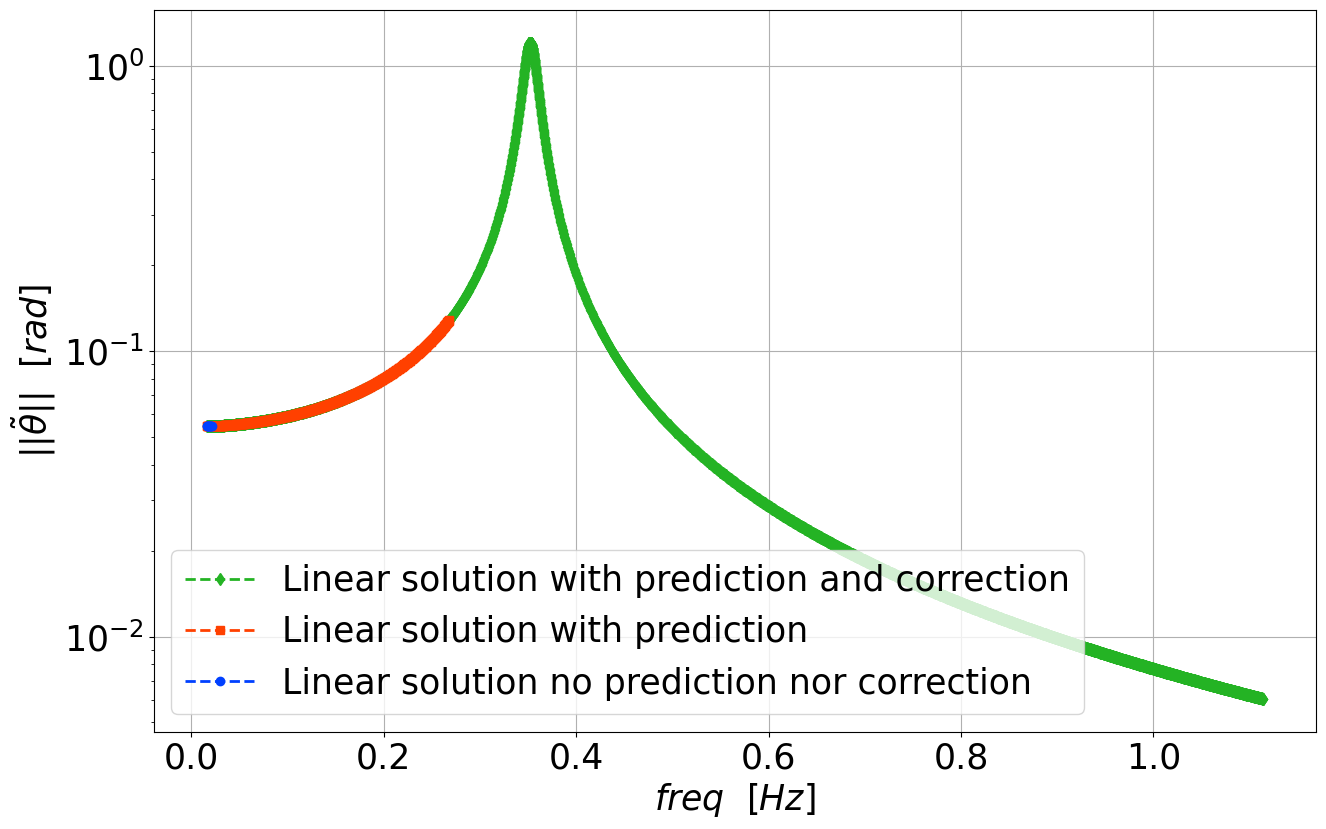

In [10]:
# -------------------- Draw of the frf -------------------- #
SA_predcor, om_predcor, ampH_predcor = get_frf(
    PredCor
)  # from the Maestro object, we extract some FRF by run the
# get_frf function defined at the top of the notebook

fig, ax = plt.subplots(figsize=ratio_fig)
ax.plot(om_predcor / (2 * np.pi), ampH_predcor, **style_plots_ref["frf_lin_predcor"])
ax.plot(om_pred / (2 * np.pi), ampH_pred, **style_plots_ref["frf_lin_pred"])
ax.plot(
    om_lin_nothing / (2 * np.pi), ampH_lin_nothing, **style_plots_ref["frf_lin_nothing"]
)
ax.set_xlabel("$freq~~[Hz]$")
ax.set_ylabel("$\|\| \\tilde{\\theta} \|\|~~[rad]$")
ax.legend()
ax.grid()
ax.set_yscale("log")

## Turning points and the importance of bifurcations
Another benefit of the prediction/correction mechanism is the handling of **turning points**. The **turning points** are specific points of the response curves and are **bifurcations** of the response curve. Their main effect is that the response curve to be followed needs to change sign in $\omega$ and those phenomena only appear when studying nonlinear systems.

In the next block we introduce the cubic nonlinearity studied in the Tuto_002 that represents an approximation of the nonlinearity present in the pendulum equation. The analysis will be run going forward the axis of angular frequency and a second analysis is create on the same exact problem but backward. 
- Complete the value needed for the cubic connector or use the function present in the correction of the previous tutorial `cubic_problem_corr`

In [11]:
from Tuto_002_AFTscheme_correctionfunctions import cubic_problem_corr


### USER MODIFICATIONS ATTENDED ###
# Now we add a new connector corresponding to the cubic part using a "CubicSpring" type
def cubic_problem(g: float, R: float) -> float:
    return 0


### END USER MODIFICATION ###


# -------------------- Cubic problem -------------------- #
INP_cub = copy.deepcopy(INP)
INP_cub["analysis"]["FRF"]["predictor"] = "tangent"
INP_cub["analysis"]["FRF_backward"] = copy.deepcopy(INP_cub["analysis"]["FRF"])
INP_cub["analysis"]["FRF_backward"]["sign_ds"] = -1

# The linearSpring connector is added like previously
INP_cub["connectors"]["linGravity"] = {
    "type": "LinearSpring",
    "connect": {"sub1": [0]},
    "dirs": [0],
    "k": g / R,
}


# Now we add a new connector corresponding to the cubic part using a "CubicSpring" type
def cubic_problem(g, R):
    return 0  # to be modified


INP_cub["connectors"]["cubicGravity"] = {
    "type": "CubicSpring",
    "connect": {"sub1": [0]},
    "dirs": [0],
    "k": cubic_problem_corr(
        g, R
    ),  # introduce the value of the coefficient to allocate to the cubic spring
}
Cub = pyHarm.Maestro(INP_cub)
Cub.operate("null")

solution converged at om=0.1
solution converged at om=0.1029999906857695
solution converged at om=0.10599998091275058
solution converged at om=0.10899997066690727
solution converged at om=0.11199995993416155
solution converged at om=0.11499994870039205
solution converged at om=0.1179999369514328
solution converged at om=0.1209999246730719
solution converged at om=0.12399991185105029
solution converged at om=0.12699989847106039
solution converged at om=0.12999988451874478
solution converged at om=0.13299986997969496
solution converged at om=0.13599985483944993
solution converged at om=0.13899983908349495
solution converged at om=0.14199982269726014
solution converged at om=0.14499980566611914
solution converged at om=0.14799978797538782
solution converged at om=0.1509997696103228
solution converged at om=0.15399975055612017
solution converged at om=0.15699973079791413
solution converged at om=0.15999971032077548
solution converged at om=0.16299968910971036
solution converged at om=0.165

solution converged at om=0.7659476038999341
solution converged at om=0.7689468624399326
solution converged at om=0.7719461164479968
solution converged at om=0.7749453645576871
solution converged at om=0.7779446058094452
solution converged at om=0.7809438395116672
solution converged at om=0.7839430651505022
solution converged at om=0.786942282331227
solution converged at om=0.7899414907398687
solution converged at om=0.792940690117812
solution converged at om=0.7959398802447892
solution converged at om=0.7989390609273359
solution converged at om=0.8019382319908482
solution converged at om=0.8049373932740458
solution converged at om=0.8079365446250605
solution converged at om=0.8109356858986377
solution converged at om=0.813934816954109
solution converged at om=0.8169339376539045
solution converged at om=0.8199330478624499
solution converged at om=0.8229321474453367
solution converged at om=0.8259312362686924
solution converged at om=0.8289303141986956
solution converged at om=0.83192938

solution converged at om=1.3981995940393812
solution converged at om=1.401188527511961
solution converged at om=1.4041772868732636
solution converged at om=1.4071658688571123
solution converged at om=1.4101542701247693
solution converged at om=1.4131424872630742
solution converged at om=1.4161305167825269
solution converged at om=1.4191183551153157
solution converged at om=1.4221059986132885
solution converged at om=1.425093443545863
solution converged at om=1.428080686097878
solution converged at om=1.4310677223673784
solution converged at om=1.4340545483633373
solution converged at om=1.4370411600033093
solution converged at om=1.4400275531110143
solution converged at om=1.4430137234138505
solution converged at om=1.4459996665403307
solution converged at om=1.448985378017444
solution converged at om=1.451970853267937
solution converged at om=1.454956087607513
solution converged at om=1.457941076241947
solution converged at om=1.4609258142641126
solution converged at om=1.463910296650

solution converged at om=1.9797069622942138
solution converged at om=1.9815624829993628
solution converged at om=1.9833948606183278
solution converged at om=1.9852039960048835
solution converged at om=1.9869898046202663
solution converged at om=1.9887522165439062
solution converged at om=1.9904911764363409
solution converged at om=1.992206643455487
solution converged at om=1.993898591127772
solution converged at om=1.9955670071759257
solution converged at om=1.99721189330551
solution converged at om=1.9988332649524936
solution converged at om=2.000431150994392
solution converged at om=2.00200559342766
solution converged at om=2.003556647014156
solution converged at om=2.005084378899603
solution converged at om=2.0065888682070288
solution converged at om=2.008070205608211
solution converged at om=2.0095284928761386
solution converged at om=2.0109638424214866
solution converged at om=2.012376376816039
solution converged at om=2.013766228305914
solution converged at om=2.0151335383173516


solution converged at om=6.844000310441154
solution converged at om=6.84100031690032
solution converged at om=6.8380003233791555
solution converged at om=6.835000329877731
solution converged at om=6.832000336396119
solution converged at om=6.82900034293439
solution converged at om=6.826000349492617
solution converged at om=6.823000356070871
solution converged at om=6.8200003626692265
solution converged at om=6.817000369287755
solution converged at om=6.814000375926531
solution converged at om=6.811000382585627
solution converged at om=6.808000389265118
solution converged at om=6.805000395965077
solution converged at om=6.80200040268558
solution converged at om=6.7990004094267
solution converged at om=6.796000416188514
solution converged at om=6.7930004229710965
solution converged at om=6.790000429774524
solution converged at om=6.787000436598872
solution converged at om=6.784000443444217
solution converged at om=6.7810004503106365
solution converged at om=6.778000457198207
solution con

...

solution converged at om=2.900700244654136
solution converged at om=2.89772315845851
solution converged at om=2.8947464709144697
solution converged at om=2.891770190501023
solution converged at om=2.8887943259084454
solution converged at om=2.885818886044231
solution converged at om=2.8828438800392306
solution converged at om=2.8798693172539775
solution converged at om=2.8768952072852088
solution converged at om=2.873921559972589
solution converged at om=2.8709483854056423
solution converged at om=2.8679756939309007
solution converged at om=2.8650034961592734
solution converged at om=2.8620318029736462
solution converged at om=2.859060625536719
solution converged at om=2.856089975299084
solution converged at om=2.853119864007564
solution converged at om=2.8501503037138027
solution converged at om=2.84718130678313
solution converged at om=2.844212885903703
solution converged at om=2.8412450540959346
solution converged at om=2.838277824722216
solution converged at om=2.835311211496947
so

solution converged at om=2.362521668792221
solution converged at om=2.3610316635414947
solution converged at om=2.359553863405664
solution converged at om=2.3580881054219547
solution converged at om=2.3566342263287496
solution converged at om=2.3551920627228045
solution converged at om=2.353761451208846
solution converged at om=2.3523422285416244
solution converged at om=2.3509342317605353
solution converged at om=2.3495372983169256
solution converged at om=2.3481512661942405
solution converged at om=2.346775974021158
solution converged at om=2.3454112611778943
solution converged at om=2.344056967895857
solution converged at om=2.3427129353508427
solution converged at om=2.341379005749981
solution converged at om=2.3400550224126273
solution converged at om=2.338740829845423
solution converged at om=2.33743627381173
solution converged at om=2.3361412013956597
solution converged at om=2.3348554610609136
solution converged at om=2.3335789027046494
solution converged at om=2.33231137770659

solution converged at om=2.1682572539633678
solution converged at om=2.167476269824974
solution converged at om=2.166695714682724
solution converged at om=2.1659155845807563
solution converged at om=2.1651358757028474
solution converged at om=2.1643565843706027
solution converged at om=2.163577707041685
solution converged at om=2.162799240308074
solution converged at om=2.162021180894365
solution converged at om=2.1612435256560936
solution converged at om=2.1604662715781
solution converged at om=2.15968941577292
solution converged at om=2.15891295547921
solution converged at om=2.158136888060204
solution converged at om=2.1573612110021965
solution converged at om=2.1565859219130608
solution converged at om=2.1558110185207924
solution converged at om=2.1550364986720822
solution converged at om=2.15426236033092
solution converged at om=2.1534886015772225
solution converged at om=2.152715220605492
solution converged at om=2.151942215723498
solution converged at om=2.151169585350991
soluti

solution converged at om=2.011536263455514
solution converged at om=2.0109083611232568
solution converged at om=2.0102820262769536
solution converged at om=2.009657272088337
solution converged at om=2.0090341118047066
solution converged at om=2.008412558748789
solution converged at om=2.0077926263185835
solution converged at om=2.007174327987196
solution converged at om=2.0065576773026543
solution converged at om=2.0059426878877105
solution converged at om=2.0053293734396265
solution converged at om=2.004717747729946
solution converged at om=2.0041078246042456
solution converged at om=2.0034996179818734
solution converged at om=2.0028931418556666
solution converged at om=2.0022884102916545
solution converged at om=2.001685437428741
solution converged at om=2.0010842374783704
solution converged at om=2.0004848247241727
solution converged at om=1.9998872135215895
solution converged at om=1.999291418297481
solution converged at om=1.998697453549712
solution converged at om=1.9981053338467

solution converged at om=1.9372724829548922
solution converged at om=1.9372203436560698
solution converged at om=1.9371722182919575
solution converged at om=1.937128116068328
solution converged at om=1.93708804861439
solution converged at om=1.9370520309251158
solution converged at om=1.9370200828025395
solution converged at om=1.9369922311821373
solution converged at om=1.9369685141608985
solution converged at om=1.9369489886735618
solution converged at om=1.9369337473201853
solution converged at om=1.936922964738671
solution not accepted at om=1.9369164862751063
solution not accepted at om=1.9369164862751063
solution not accepted at om=1.9369164862751063
solution not accepted at om=1.9369164862751063
solution not accepted at om=1.9369164862751063
solution not accepted at om=1.9369164862751063
solution not accepted at om=1.9369164862751063
solution not accepted at om=1.9369164862751063
solution not accepted at om=1.9369164862751063
solution not accepted at om=1.9369164862751063
Wall c

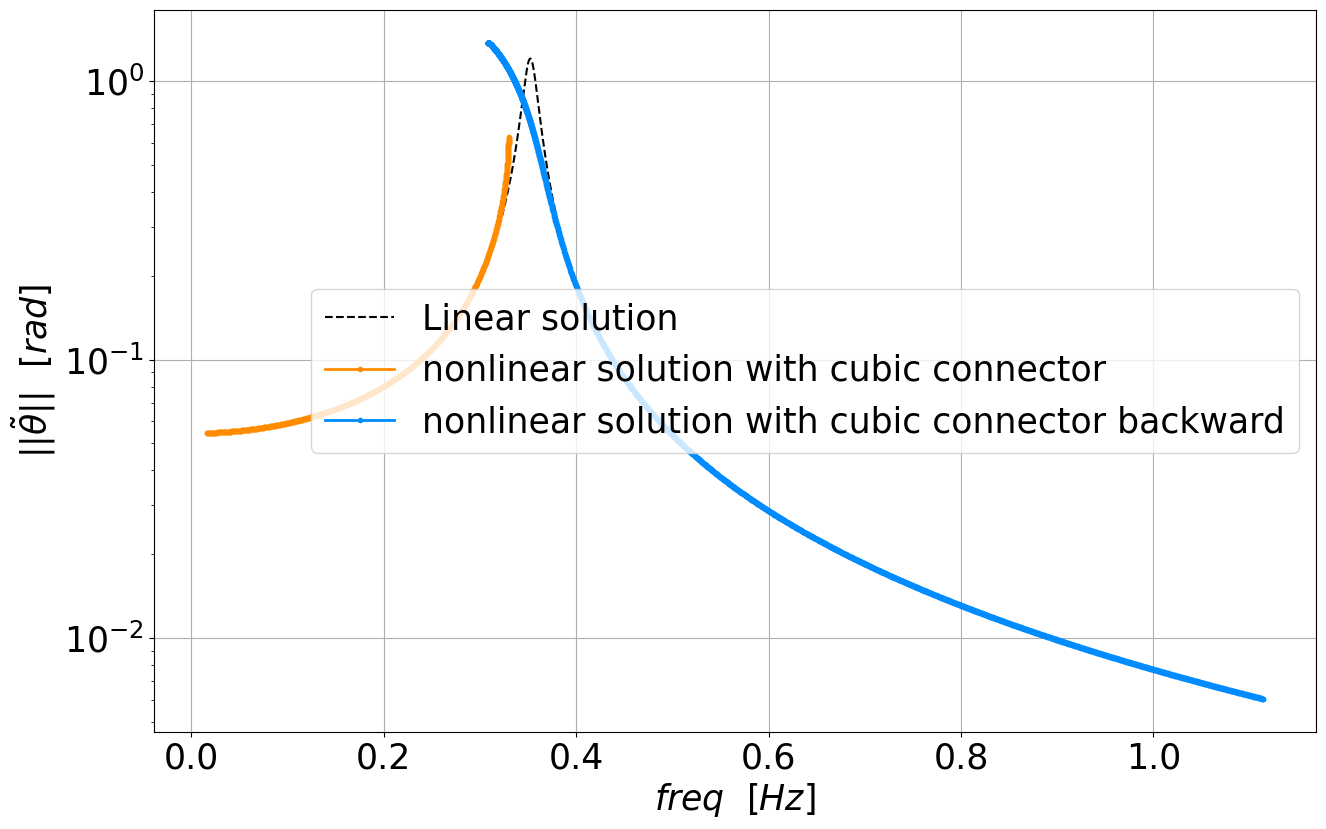

In [12]:
SA_cub, om_cub, ampH_cub = get_frf(Cub)
SA_cubB, om_cubB, ampH_cubB = get_frf(Cub, analysis="FRF_backward")

fig, ax = plt.subplots(figsize=ratio_fig)
ax.plot(om_predcor / (2 * np.pi), ampH_predcor, **style_plots_ref["frf_lin"])
ax.plot(om_cub / (2 * np.pi), ampH_cub, **style_plots_ref["frf_nl_cubic"])
ax.plot(om_cubB / (2 * np.pi), ampH_cubB, **style_plots_ref["frf_nl_cubicB"])
ax.set_xlabel("$freq~~[Hz]$")
ax.set_ylabel("$\|\| \\tilde{\\theta} \|\|~~[rad]$")
ax.legend()
ax.grid()
ax.set_yscale("log")

Using only a predictor and keeping the corrector to impose a fix $\omega$ the solver is not able to converge on the solution branch. The points where the solver fail are turning points and can be detected using test functions when more complex corrector equations are used. Once the **turning point** is detected, the code knows that the direction of prediction needs to change sign and does it accordingly. 

In [13]:
INP_cub_bifurc = copy.deepcopy(INP)
INP_cub_bifurc["analysis"]["FRF"]["predictor"] = "tangent"
INP_cub_bifurc["analysis"]["FRF"]["corrector"] = "pseudo_arc_length"

# The linearSpring connector is added like previously
INP_cub_bifurc["connectors"]["linGravity"] = {
    "type": "LinearSpring",
    "connect": {"sub1": [0]},
    "dirs": [0],
    "k": g / R,
}


# Now we add a new connector corresponding to the cubic part using a "CubicSpring" type
def cubic_problem(g, R):
    return 0  # to be modified


INP_cub_bifurc["connectors"]["cubicGravity"] = {
    "type": "CubicSpring",
    "connect": {"sub1": [0]},
    "dirs": [0],
    "k": cubic_problem_corr(
        g, R
    ),  # introduce the value of the coefficient to allocate to the cubic spring
}
Cub_bifurc = pyHarm.Maestro(INP_cub_bifurc)
Cub_bifurc.operate("null")

solution converged at om=0.1
solution converged at om=0.10299999045980822
solution converged at om=0.10599998045381692
solution converged at om=0.10899996996796936
solution converged at om=0.11199995898816603
solution converged at om=0.11499994750026349
solution converged at om=0.11799993549007302
solution converged at om=0.12099992294335937
solution converged at om=0.12399990984583943
solution converged at om=0.12699989618318092
solution converged at om=0.1299998819410011
solution converged at om=0.13299986710486544
solution converged at om=0.1359998516602863
solution converged at om=0.1389998355927216
solution converged at om=0.1419998188875735
solution converged at om=0.14499980153018688
solution converged at om=0.14799978350584828
solution converged at om=0.15099976479978428
solution converged at om=0.15399974539716024
solution converged at om=0.1569997252830789
solution converged at om=0.15999970444257897
solution converged at om=0.16299968286063374
solution converged at om=0.1659

solution converged at om=0.6669689882393343
solution converged at om=0.669968500584508
solution converged at om=0.6729680066648855
solution converged at om=0.6759675063822232
solution converged at om=0.6789669996285584
solution converged at om=0.6819664862831107
solution converged at om=0.6849659662079277
solution converged at om=0.6879654392416965
solution converged at om=0.69096490519083
solution converged at om=0.6939643638164628
solution converged at om=0.6969638148152307
solution converged at om=0.6999632577905048
solution converged at om=0.7029626922088498
solution converged at om=0.7059621173335299
solution converged at om=0.7089615321225167
solution converged at om=0.7119609350726601
solution converged at om=0.7149603239861593
solution converged at om=0.7179596956375837
solution converged at om=0.7209590453523897
solution converged at om=0.7239583666282426
solution converged at om=0.7269576512393754
solution converged at om=0.7299568907976487
solution converged at om=0.73295608

solution converged at om=1.3114537453245152
solution converged at om=1.3144465255668984
solution converged at om=1.3174392007446163
solution converged at om=1.3204317690601461
solution converged at om=1.323424228679563
solution converged at om=1.326416577731687
solution converged at om=1.3294088143072056
solution converged at om=1.3324009364577747
solution converged at om=1.3353929421950945
solution converged at om=1.3383848294899614
solution converged at om=1.3413765962712934
solution converged at om=1.3443682404251294
solution converged at om=1.3473597597936025
solution converged at om=1.350351152173884
solution converged at om=1.353342415317099
solution converged at om=1.3563335469272133
solution converged at om=1.3593245446598883
solution converged at om=1.3623154061213056
solution converged at om=1.3653061288669586
solution converged at om=1.3682967104004111
solution converged at om=1.3712871481720206
solution converged at om=1.3742774395776276
solution converged at om=1.377267581

solution converged at om=1.9237036366299072
solution converged at om=1.9260786466902384
solution converged at om=1.928437073529367
solution converged at om=1.9307785807666173
solution converged at om=1.933102834152407
solution converged at om=1.935409502192594
solution converged at om=1.9376982567862153
solution converged at om=1.9399687738738567
solution converged at om=1.942220734093666
solution converged at om=1.9444538234418485
solution converged at om=1.9466677339343041
solution converged at om=1.94886216426593
solution converged at om=1.9510368204640098
solution converged at om=1.9531914165320337
solution converged at om=1.9553256750802601
solution converged at om=1.957439327939334
solution converged at om=1.9595321167533155
solution converged at om=1.961603793548566
solution converged at om=1.9636541212750565
solution converged at om=1.9656828743168315
solution converged at om=1.9676898389685653
solution converged at om=1.9696748138753821
solution converged at om=1.9716376104333

solution converged at om=2.0653977654164364
solution converged at om=2.0651738805831914
solution converged at om=2.064946976015814
solution converged at om=2.0647170824609926
solution converged at om=2.064484230335684
solution converged at om=2.0642484497330487
solution converged at om=2.064009770428276
solution converged at om=2.0637682218842897
solution converged at om=2.0635238332573533
solution converged at om=2.063276633402559
solution converged at om=2.0630266508792134
solution converged at om=2.062773913956127
solution converged at om=2.062518450616794
solution converged at om=2.0622602885644787
solution converged at om=2.061999455227208
solution converged at om=2.0617359777626634
solution converged at om=2.061469883062989
solution converged at om=2.0612011977595035
solution converged at om=2.0609299482273276
solution converged at om=2.0606561605899247
solution converged at om=2.0603798607235597
solution converged at om=2.060101074261671
solution converged at om=2.05981982659916

...

solution converged at om=4.038936163309648
solution converged at om=4.041935754942141
solution converged at om=4.044935349419326
solution converged at om=4.0479349467171515
solution converged at om=4.050934546811804
solution converged at om=4.053934149679707
solution converged at om=4.056933755297521
solution converged at om=4.059933363642137
solution converged at om=4.062932974690676
solution converged at om=4.065932588420483
solution converged at om=4.068932204809131
solution converged at om=4.07193182383441
solution converged at om=4.074931445474332
solution converged at om=4.077931069707125
solution converged at om=4.0809306965112295
solution converged at om=4.083930325865299
solution converged at om=4.086929957748194
solution converged at om=4.089929592138985
solution converged at om=4.092929229016944
solution converged at om=4.095928868361547
solution converged at om=4.0989285101524695
solution converged at om=4.101928154369583
solution converged at om=4.1049278009929555
solution

solution converged at om=4.617890993332563
solution converged at om=4.620890868705503
solution converged at om=4.623890744754595
solution converged at om=4.626890621475415
solution converged at om=4.629890498863573
solution converged at om=4.632890376914716
solution converged at om=4.635890255624521
solution converged at om=4.638890134988699
solution converged at om=4.6418900150029945
solution converged at om=4.644889895663184
solution converged at om=4.6478897769650755
solution converged at om=4.650889658904511
solution converged at om=4.653889541477362
solution converged at om=4.656889424679533
solution converged at om=4.659889308506959
solution converged at om=4.662889192955606
solution converged at om=4.665889078021469
solution converged at om=4.668888963700577
solution converged at om=4.671888849988985
solution converged at om=4.674888736882781
solution converged at om=4.677888624378078
solution converged at om=4.680888512471025
solution converged at om=4.683888401157795
solution 

solution converged at om=5.247874882460178
solution converged at om=5.250874837842264
solution converged at om=5.253874793420909
solution converged at om=5.2568747491950765
solution converged at om=5.2598747051637345
solution converged at om=5.262874661325858
solution converged at om=5.265874617680428
solution converged at om=5.268874574226431
solution converged at om=5.271874530962863
solution converged at om=5.274874487888723
solution converged at om=5.2778744450030155
solution converged at om=5.280874402304755
solution converged at om=5.283874359792958
solution converged at om=5.2868743174666495
solution converged at om=5.289874275324859
solution converged at om=5.292874233366623
solution converged at om=5.295874191590984
solution converged at om=5.2988741499969905
solution converged at om=5.301874108583695
solution converged at om=5.304874067350156
solution converged at om=5.3078740262954405
solution converged at om=5.310873985418619
solution converged at om=5.313873944718767
solut

solution converged at om=5.901868486068167
solution converged at om=5.90486846758872
solution converged at om=5.907868449177753
solution converged at om=5.910868430834963
solution converged at om=5.913868412560049
solution converged at om=5.916868394352712
solution converged at om=5.919868376212653
solution converged at om=5.922868358139576
solution converged at om=5.925868340133186
solution converged at om=5.928868322193189
solution converged at om=5.931868304319294
solution converged at om=5.93486828651121
solution converged at om=5.937868268768647
solution converged at om=5.940868251091318
solution converged at om=5.9438682334789394
solution converged at om=5.946868215931223
solution converged at om=5.949868198447888
solution converged at om=5.952868181028651
solution converged at om=5.955868163673233
solution converged at om=5.958868146381354
solution converged at om=5.961868129152738
solution converged at om=5.9648681119871085
solution converged at om=5.967868094884191
solution co

solution converged at om=6.5528656841969966
solution converged at om=6.555865675461668
solution converged at om=6.558865666754392
solution converged at om=6.561865658075061
solution converged at om=6.564865649423569
solution converged at om=6.567865640799811
solution converged at om=6.570865632203679
solution converged at om=6.573865623635069
solution converged at om=6.576865615093878
solution converged at om=6.579865606579999
solution converged at om=6.5828655980933295
solution converged at om=6.585865589633766
solution converged at om=6.588865581201206
solution converged at om=6.591865572795546
solution converged at om=6.594865564416685
solution converged at om=6.597865556064521
solution converged at om=6.600865547738953
solution converged at om=6.60386553943988
solution converged at om=6.606865531167203
solution converged at om=6.6098655229208205
solution converged at om=6.612865514700634
solution converged at om=6.615865506506546
solution converged at om=6.618865498338456
solution 

Before going to the figure, look at the printing log emitted during the analysis. Once fold bifurcation is detected the code changes the direction of prediction in order to follow the curve when the sign of $\delta \omega$ needs to change

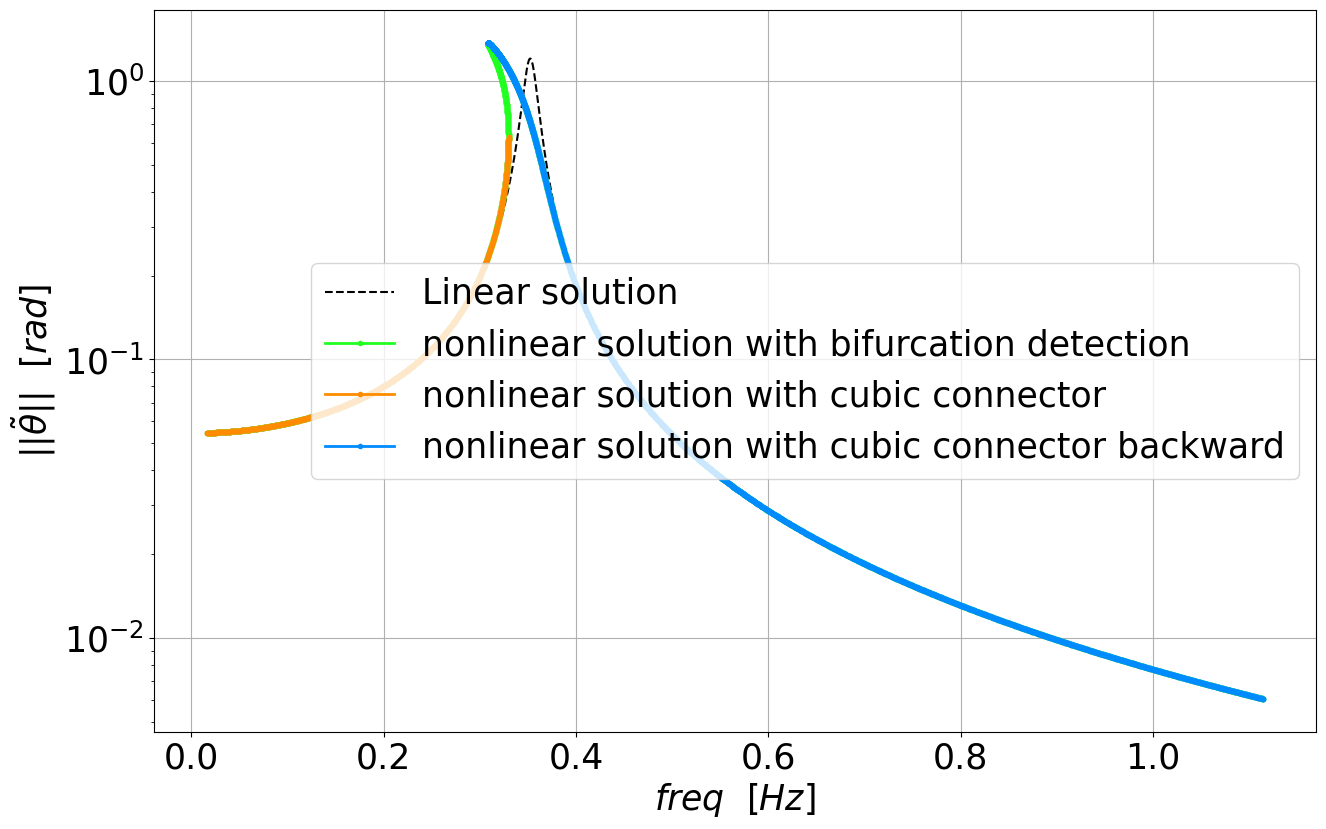

In [14]:
SA_cub_bifurc, om_cub_bifurc, ampH_cub_bifurc = get_frf(Cub_bifurc)

fig, ax = plt.subplots(figsize=ratio_fig)
ax.plot(om_predcor / (2 * np.pi), ampH_predcor, **style_plots_ref["frf_lin"])
ax.plot(
    om_cub_bifurc / (2 * np.pi), ampH_cub_bifurc, **style_plots_ref["frf_nl_bifurc"]
)
ax.plot(om_cub / (2 * np.pi), ampH_cub, **style_plots_ref["frf_nl_cubic"])
ax.plot(om_cubB / (2 * np.pi), ampH_cubB, **style_plots_ref["frf_nl_cubicB"])
ax.set_xlabel("$freq~~[Hz]$")
ax.set_ylabel("$\|\| \\tilde{\\theta} \|\|~~[rad]$")
ax.legend()
ax.grid()
ax.set_yscale("log")

# Conclusion 

The prediction/correction method serves more than a single purpose in the HBM framework. On one side it allows to give the nonlinear solver a better initial guess helping on obtaining the convergence and on the speed of the convergence. On the second hand the correction term allows for more flexibility to the solver that is able to look for a solution in a bigger space by acting onto the angular frequency itself ensuring a better convergence rate as well. But this augmented system of equations also allows to detect and treat specific points with more accuracy. The turning points can become quite challenging or even not possible to solve if they are not detected and treated the right way. 

The next tutorial will be addressing friction mechanisms.

